In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
CAMERA = "Farm"
BUILDING = "B160M"

In [52]:
calib_dir = f"{CAMERA} calibration 25-03-2026"
calib_dir

'Farm calibration 25-03-2026'

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


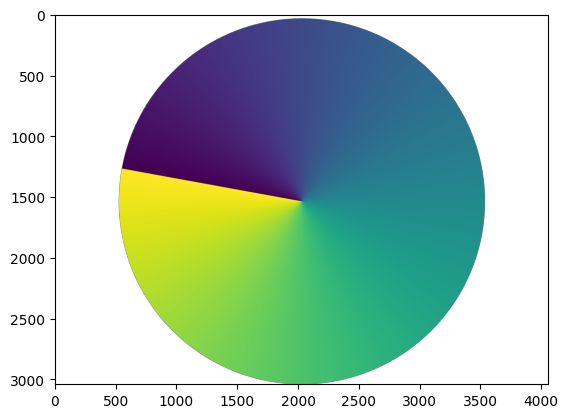

In [53]:
import glob

az_files = glob.glob(f"{CAMERA} calibration 25-03-2026\\azimuth_matrix_{CAMERA}_*.npy")
if len(az_files) == 0:
    raise FileNotFoundError("No azimuth matrix files found with the given pattern.")
az_matrix = np.load(az_files[0])
az_matrix[0,0] = np.nan
print(az_matrix)
plt.imshow(az_matrix)

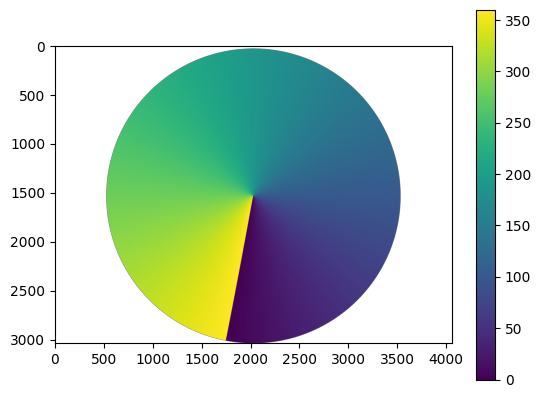

In [54]:
north_azimuth_matrix = (90-np.degrees(az_matrix))%360
plt.imshow(north_azimuth_matrix)
plt.colorbar()
plt.savefig(f"{CAMERA} calibration 25-03-2026\\SPVS_ASI_Wematics_{BUILDING}_{CAMERA}_azimuth_matrix_north.png")
# save (np.degrees(az_matrix)+270)%360 as azimuth_matrix_Wind.npy
np.save(f"{CAMERA} calibration 25-03-2026\\SPVS_ASI_Wematics_{BUILDING}_{CAMERA}_azimuth_matrix_north.npy", north_azimuth_matrix)


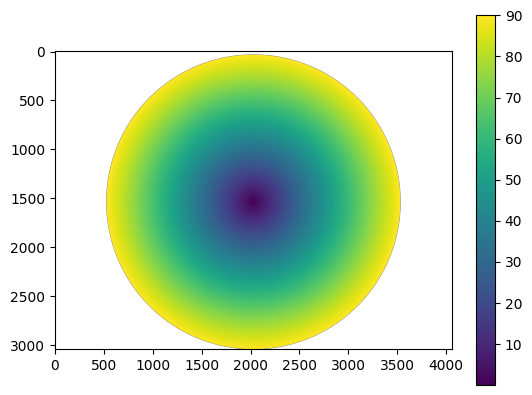

In [55]:
import glob

ele_files = glob.glob(f"{CAMERA} calibration 25-03-2026\\elevation_matrix_{CAMERA}_*.npy")
if len(ele_files) == 0:
    raise FileNotFoundError("No elevation matrix files found with the given pattern.")
ele_matrix = np.load(ele_files[0])
zenith_matrix = 90 - np.degrees(ele_matrix)
# set gt 85 to np.nan
#zenith_matrix[zenith_matrix > 85] = np.nan
plt.imshow(zenith_matrix)
plt.colorbar()
plt.savefig(f"{CAMERA} calibration 25-03-2026\\SPVS_ASI_Wematics_{BUILDING}_{CAMERA}_zenith_matrix.png")

In [56]:
# write a zenith matrix (90 - elevation)
np.save(f"{CAMERA} calibration 25-03-2026\\SPVS_ASI_Wematics_{BUILDING}_{CAMERA}_zenith_matrix.npy", zenith_matrix)
